## 音声処理の基礎


---

このノートブックの目的はpythonで音声から特徴量を抽出する方法を理解することです

順番にコードを実行して確認しましょう

---


### 音声をスペクトログラムに変換する

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 音声ファイルのパス
audio_path = "../data/test/testaudio.mp3"


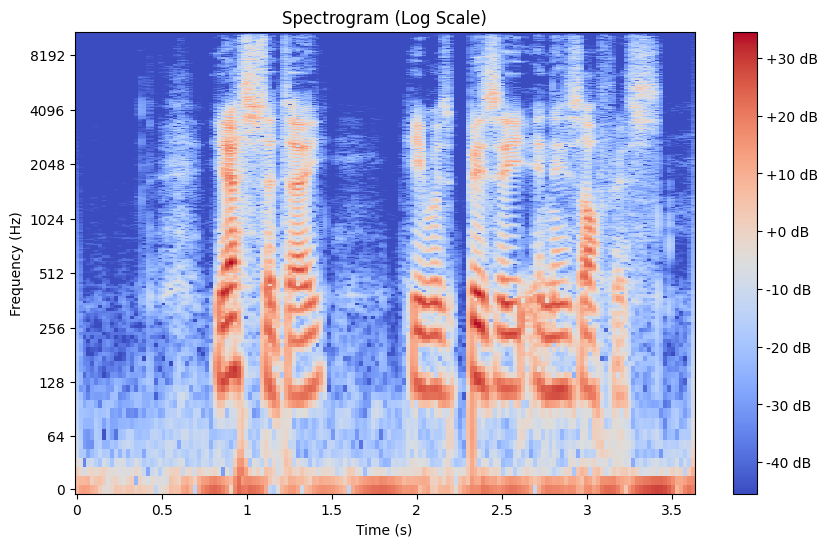

In [ ]:
# 音声ファイルの読み込み
# y: 音声信号（波形データ）, sr: サンプリングレート
y, sr = librosa.load(audio_path, sr=22050)  # sr=Noneを指定すると元のサンプリングレートが維持されます

# 短時間フーリエ変換（STFT）を計算
stft = librosa.stft(y, n_fft=2048, hop_length=512)

# 振幅スペクトル（絶対値を取る）
spectrogram = np.abs(stft)

# 対数振幅スペクトル（dB単位）
log_spectrogram = librosa.amplitude_to_db(spectrogram)

# スペクトログラムのプロット
plt.figure(figsize=(10, 6))
librosa.display.specshow(log_spectrogram, sr=sr, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Log Scale)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

In [7]:
log_spectrogram

array([[  8.176865 ,  12.681932 ,  13.495272 , ...,  18.527195 ,
         21.13016  ,  19.365791 ],
       [  6.5787787,   7.967007 ,   7.1565847, ...,  13.040471 ,
         16.229465 ,  17.005955 ],
       [  1.926607 ,  -3.0728698,  -7.9710507, ..., -14.2416525,
          1.917774 ,   9.74291  ],
       ...,
       [-45.454266 , -45.454266 , -45.454266 , ..., -45.454266 ,
        -45.454266 , -45.454266 ],
       [-45.454266 , -45.454266 , -45.454266 , ..., -45.454266 ,
        -45.454266 , -45.454266 ],
       [-45.454266 , -45.454266 , -45.454266 , ..., -45.454266 ,
        -45.454266 , -45.454266 ]], dtype=float32)

### 音声をMelSpectrogramに変換する

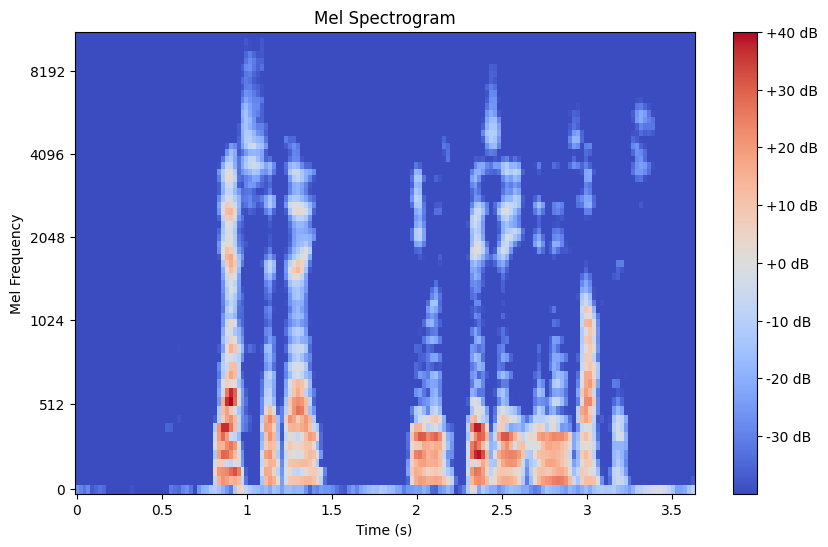

In [4]:
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=64)
log_mel_spectrogram = librosa.amplitude_to_db(mel_spectrogram) # dBスケールに変換

plt.figure(figsize=(10, 6))
librosa.display.specshow(log_mel_spectrogram, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Mel Frequency")
plt.show()

In [6]:
log_mel_spectrogram

array([[-27.402143, -29.435703, -32.738464, ..., -21.23439 , -14.485563,
         -9.346618],
       [-39.973724, -39.973724, -39.973724, ..., -39.973724, -39.973724,
        -36.959343],
       [-39.973724, -39.973724, -39.973724, ..., -39.973724, -39.973724,
        -39.973724],
       ...,
       [-39.973724, -39.973724, -39.973724, ..., -39.973724, -39.973724,
        -39.973724],
       [-39.973724, -39.973724, -39.973724, ..., -39.973724, -39.973724,
        -39.973724],
       [-39.973724, -39.973724, -39.973724, ..., -39.973724, -39.973724,
        -39.973724]], dtype=float32)

### 音声をWav2vec2.0で特徴量に変換

音声データから特徴量を抽出するための自己教師あり学習モデル(ラベルなしデータで事前学習を行った後ラベルつきデータでファインチューニングを行う)

音声データを特徴エンコーダ(Conv)で特徴量に変換し、量子化、一部をマスクしてコンテキストネットワーク(Transformer)に入力、マスクしたタイムステップの出力とマスクした特徴量で対照損失を計算することで学習する

文字起こしなどの音声認識で使用されるWav2vec2.0は音響情報をあまり含んでいないと言われているため、音声分類モデルにあまり適していない

---

Wav2vec2.0をファインチューニングするのは少し難しいので、今回はファインチューニング済みモデルを使用して特徴量を抽出して別のNNで分類するための学習を行ってみます

wav2vec2-base-960hは 16kHz でサンプリングされた音声オーディオで 960 時間の Librispeech で事前トレーニングおよびファインチューニングされています

モデルへの音声入力は 16KHz にリサンプリングする必要があります

In [ ]:
!pip install --upgrade transformers

In [8]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torchaudio

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

target_sampling_rate = processor.feature_extractor.sampling_rate
audio, sr = torchaudio.load(audio_path)
x = torchaudio.transforms.Resample(sr, target_sampling_rate)(audio[0]).numpy()
x = processor(x,sampling_rate=16000,return_tensors="pt") #wavファイルをwav2vecに入れる前の処理 pt:pytorchのテンソル
x = model(**x).last_hidden_state #wav2vecにwavファイルを入力
x

Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tensor([[[ 0.0056, -0.0196, -0.1117,  ..., -0.2117,  0.0734, -0.0855],
         [ 0.0081, -0.0202, -0.1201,  ..., -0.2092,  0.0756, -0.0894],
         [ 0.0090, -0.0183, -0.1070,  ..., -0.2089,  0.0724, -0.0959],
         ...,
         [-0.0017, -0.0279, -0.1505,  ..., -0.1995,  0.0697, -0.0744],
         [-0.0070, -0.0323, -0.1602,  ..., -0.2030,  0.0734, -0.0648],
         [-0.0091, -0.0373, -0.1608,  ..., -0.2134,  0.0766, -0.0530]]],
       grad_fn=<NativeLayerNormBackward0>)

In [12]:
len(x[0])

181

In [13]:
len(x[0][0])

768